# Membryo results

E9.5–E11.5.

## Settings

In [ ]:
from pathlib import Path
import yaml

DATASET = 'Membryo'
CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / DATASET
REPO_ROOT = EXPERIMENT_DIR.parents[1]
import sys

CONFIG = yaml.safe_load(
    (EXPERIMENT_DIR / "config.yaml").read_text(encoding="utf-8")
)

def experiment_path(value):
    path = Path(value)
    return path if path.is_absolute() else (EXPERIMENT_DIR / path).resolve()

RUN_ROOT = experiment_path(CONFIG["run_root"])
SCANVI_DIR = experiment_path(CONFIG["scanvi_dir"])
SCANVI_ADATA = SCANVI_DIR / "adata.h5ad"
STAGE1_CHECKPOINT_ROOT = experiment_path(CONFIG["stage1_checkpoint"])

import json
sys.path.insert(0, str(REPO_ROOT))
from tutorial_utils.frame_gallery import load_gallery, plot_gallery

PALETTE = json.loads((EXPERIMENT_DIR / "colors.json").read_text())
ROUTE_IDS = list(CONFIG["route_ids"])
ROUTES = list(zip(ROUTE_IDS[:-1], ROUTE_IDS[1:]))
INPUT_PATH = SCANVI_ADATA
INTERVAL = 1


## Simulation frames

In [ ]:
segments = []
for src, tgt in ROUTES:
    route = f"{src}_to_{tgt}"
    frame_dir = RUN_ROOT / "simulation" / route
    segments.append({"src": src, "tgt": tgt, "frame_dir": frame_dir,
                     "checkpoint": STAGE1_CHECKPOINT_ROOT / route / "checkpoints" / "best.pt"})

panels = load_gallery(INPUT_PATH, 'timepoint', CONFIG["celltype_source_key"],
                      segments, dimension=CONFIG["spatial_dimension"], interval=INTERVAL)


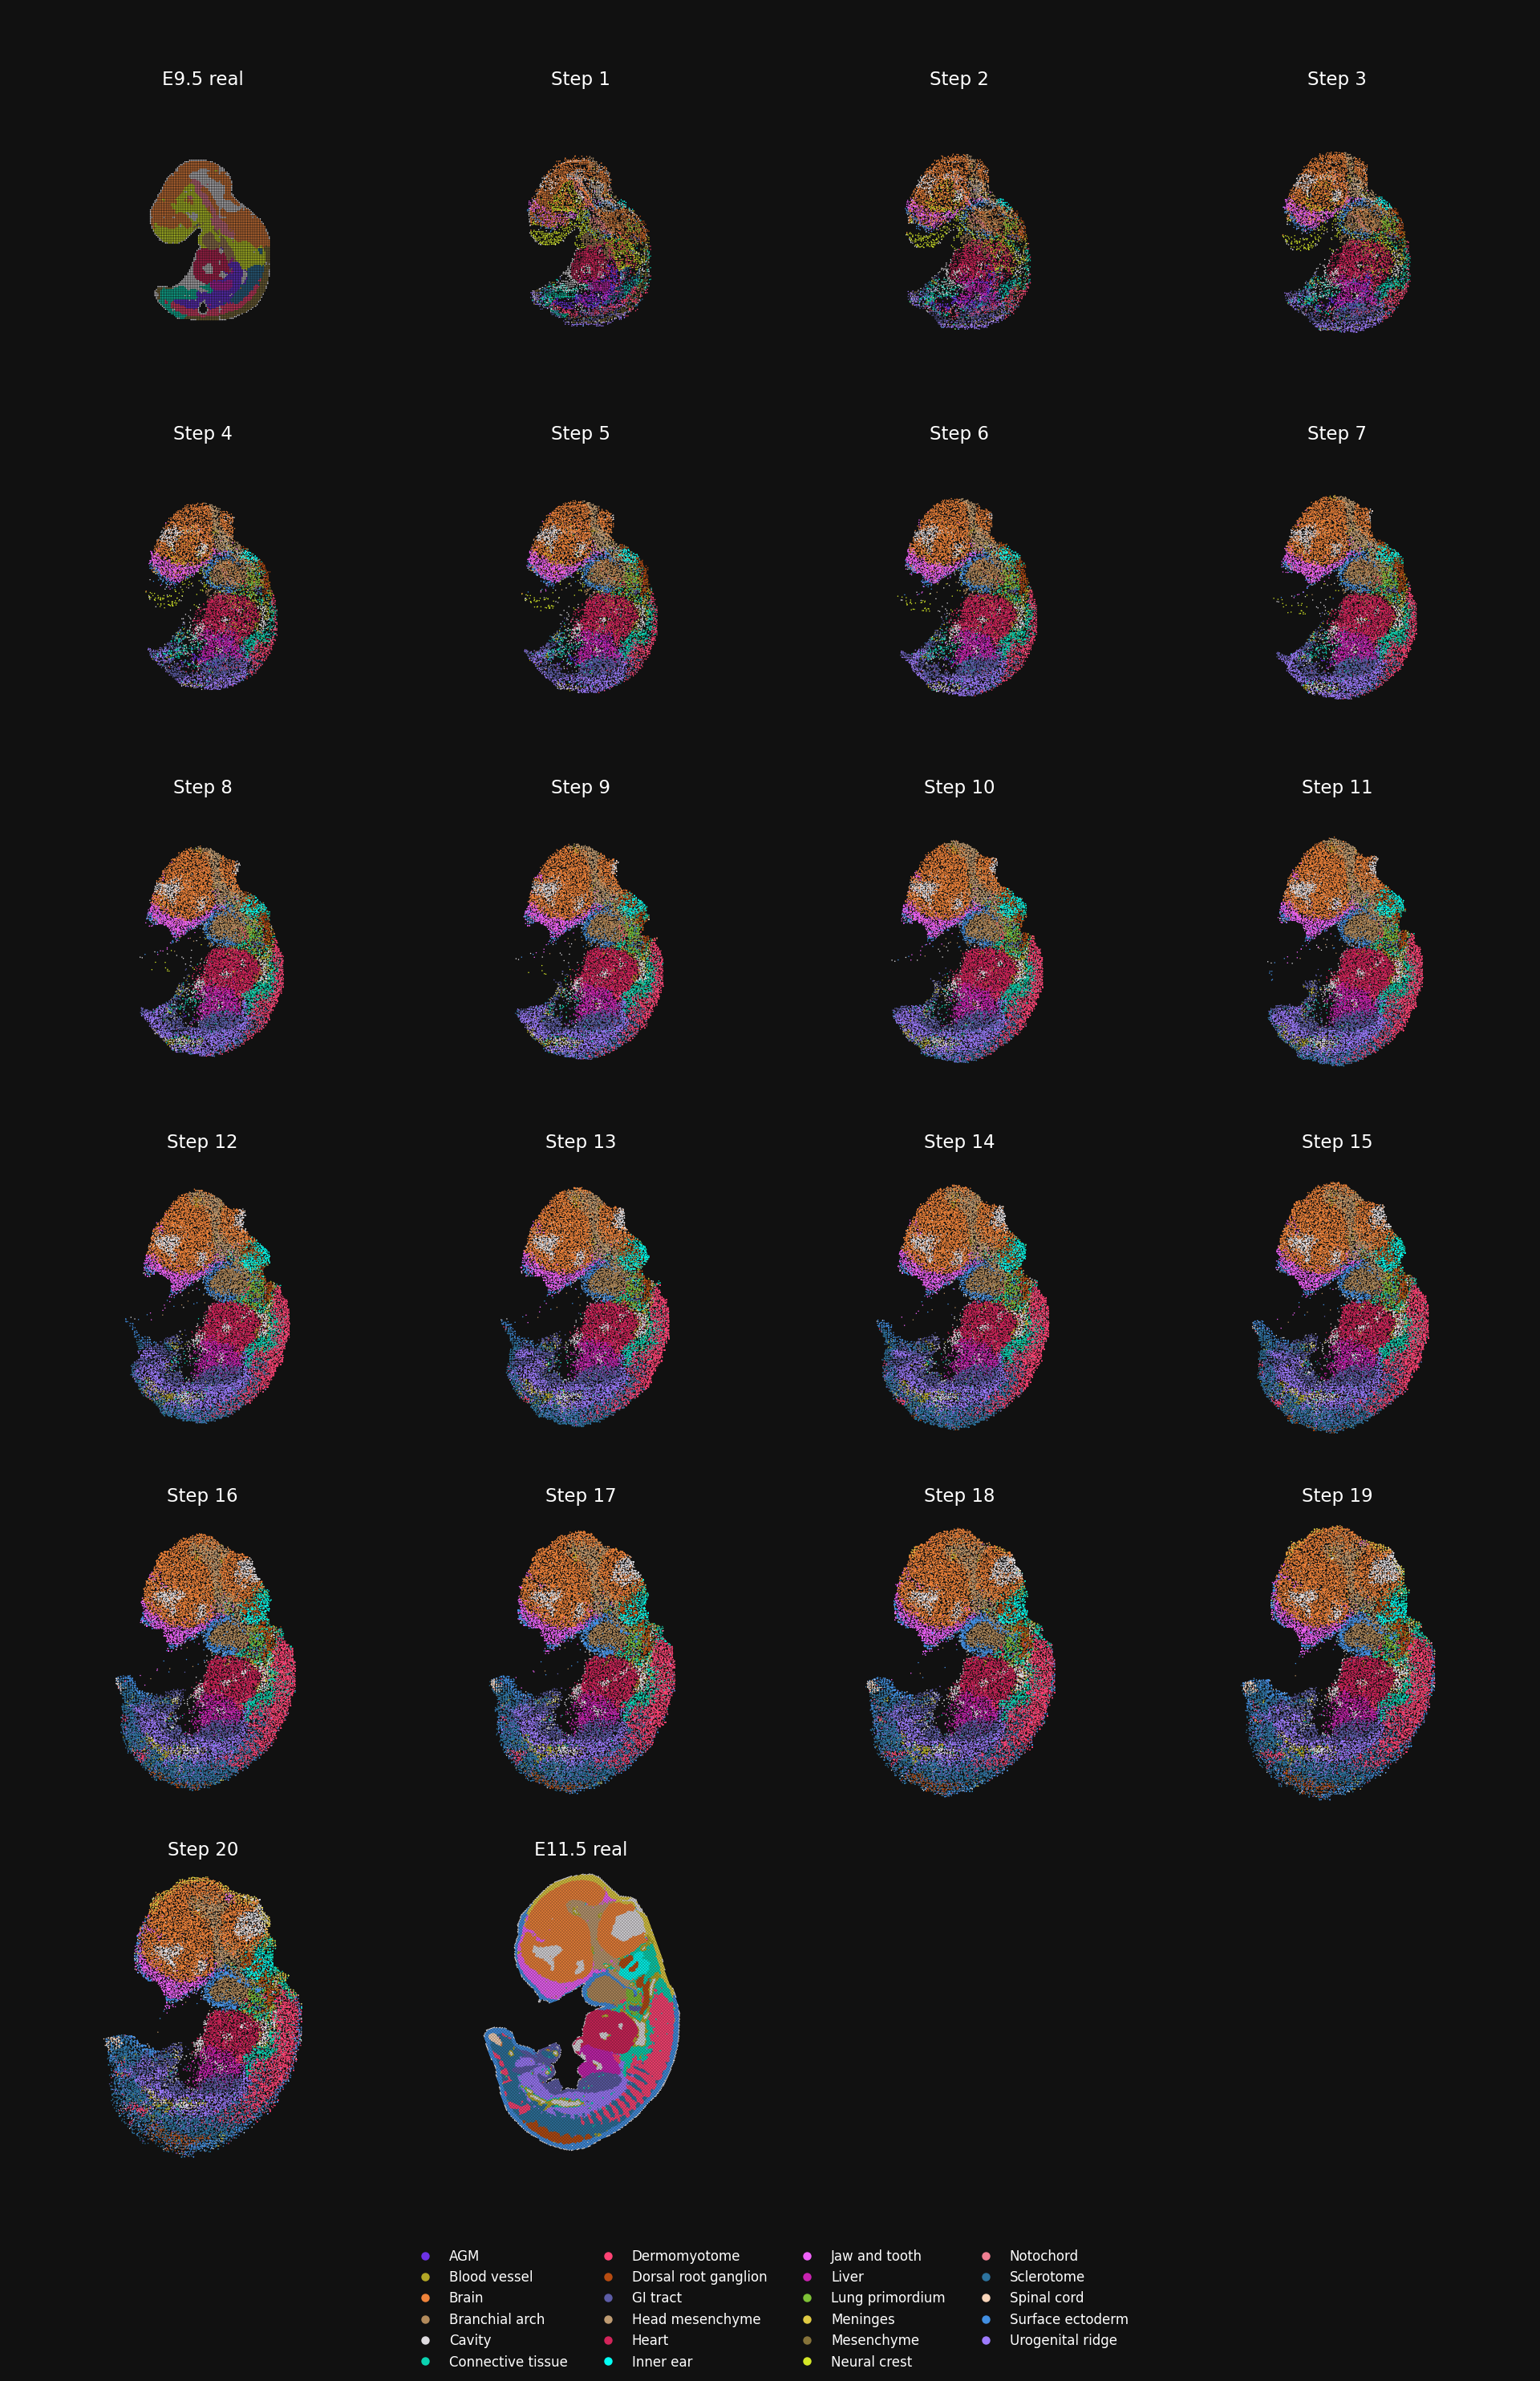

In [ ]:
fig = plot_gallery(panels, PALETTE, dimension=CONFIG["spatial_dimension"],
                   flip_y=True)
import matplotlib.pyplot as plt
plt.show()

## Gene correlation heatmaps

Real and stVirtual at E10.5.

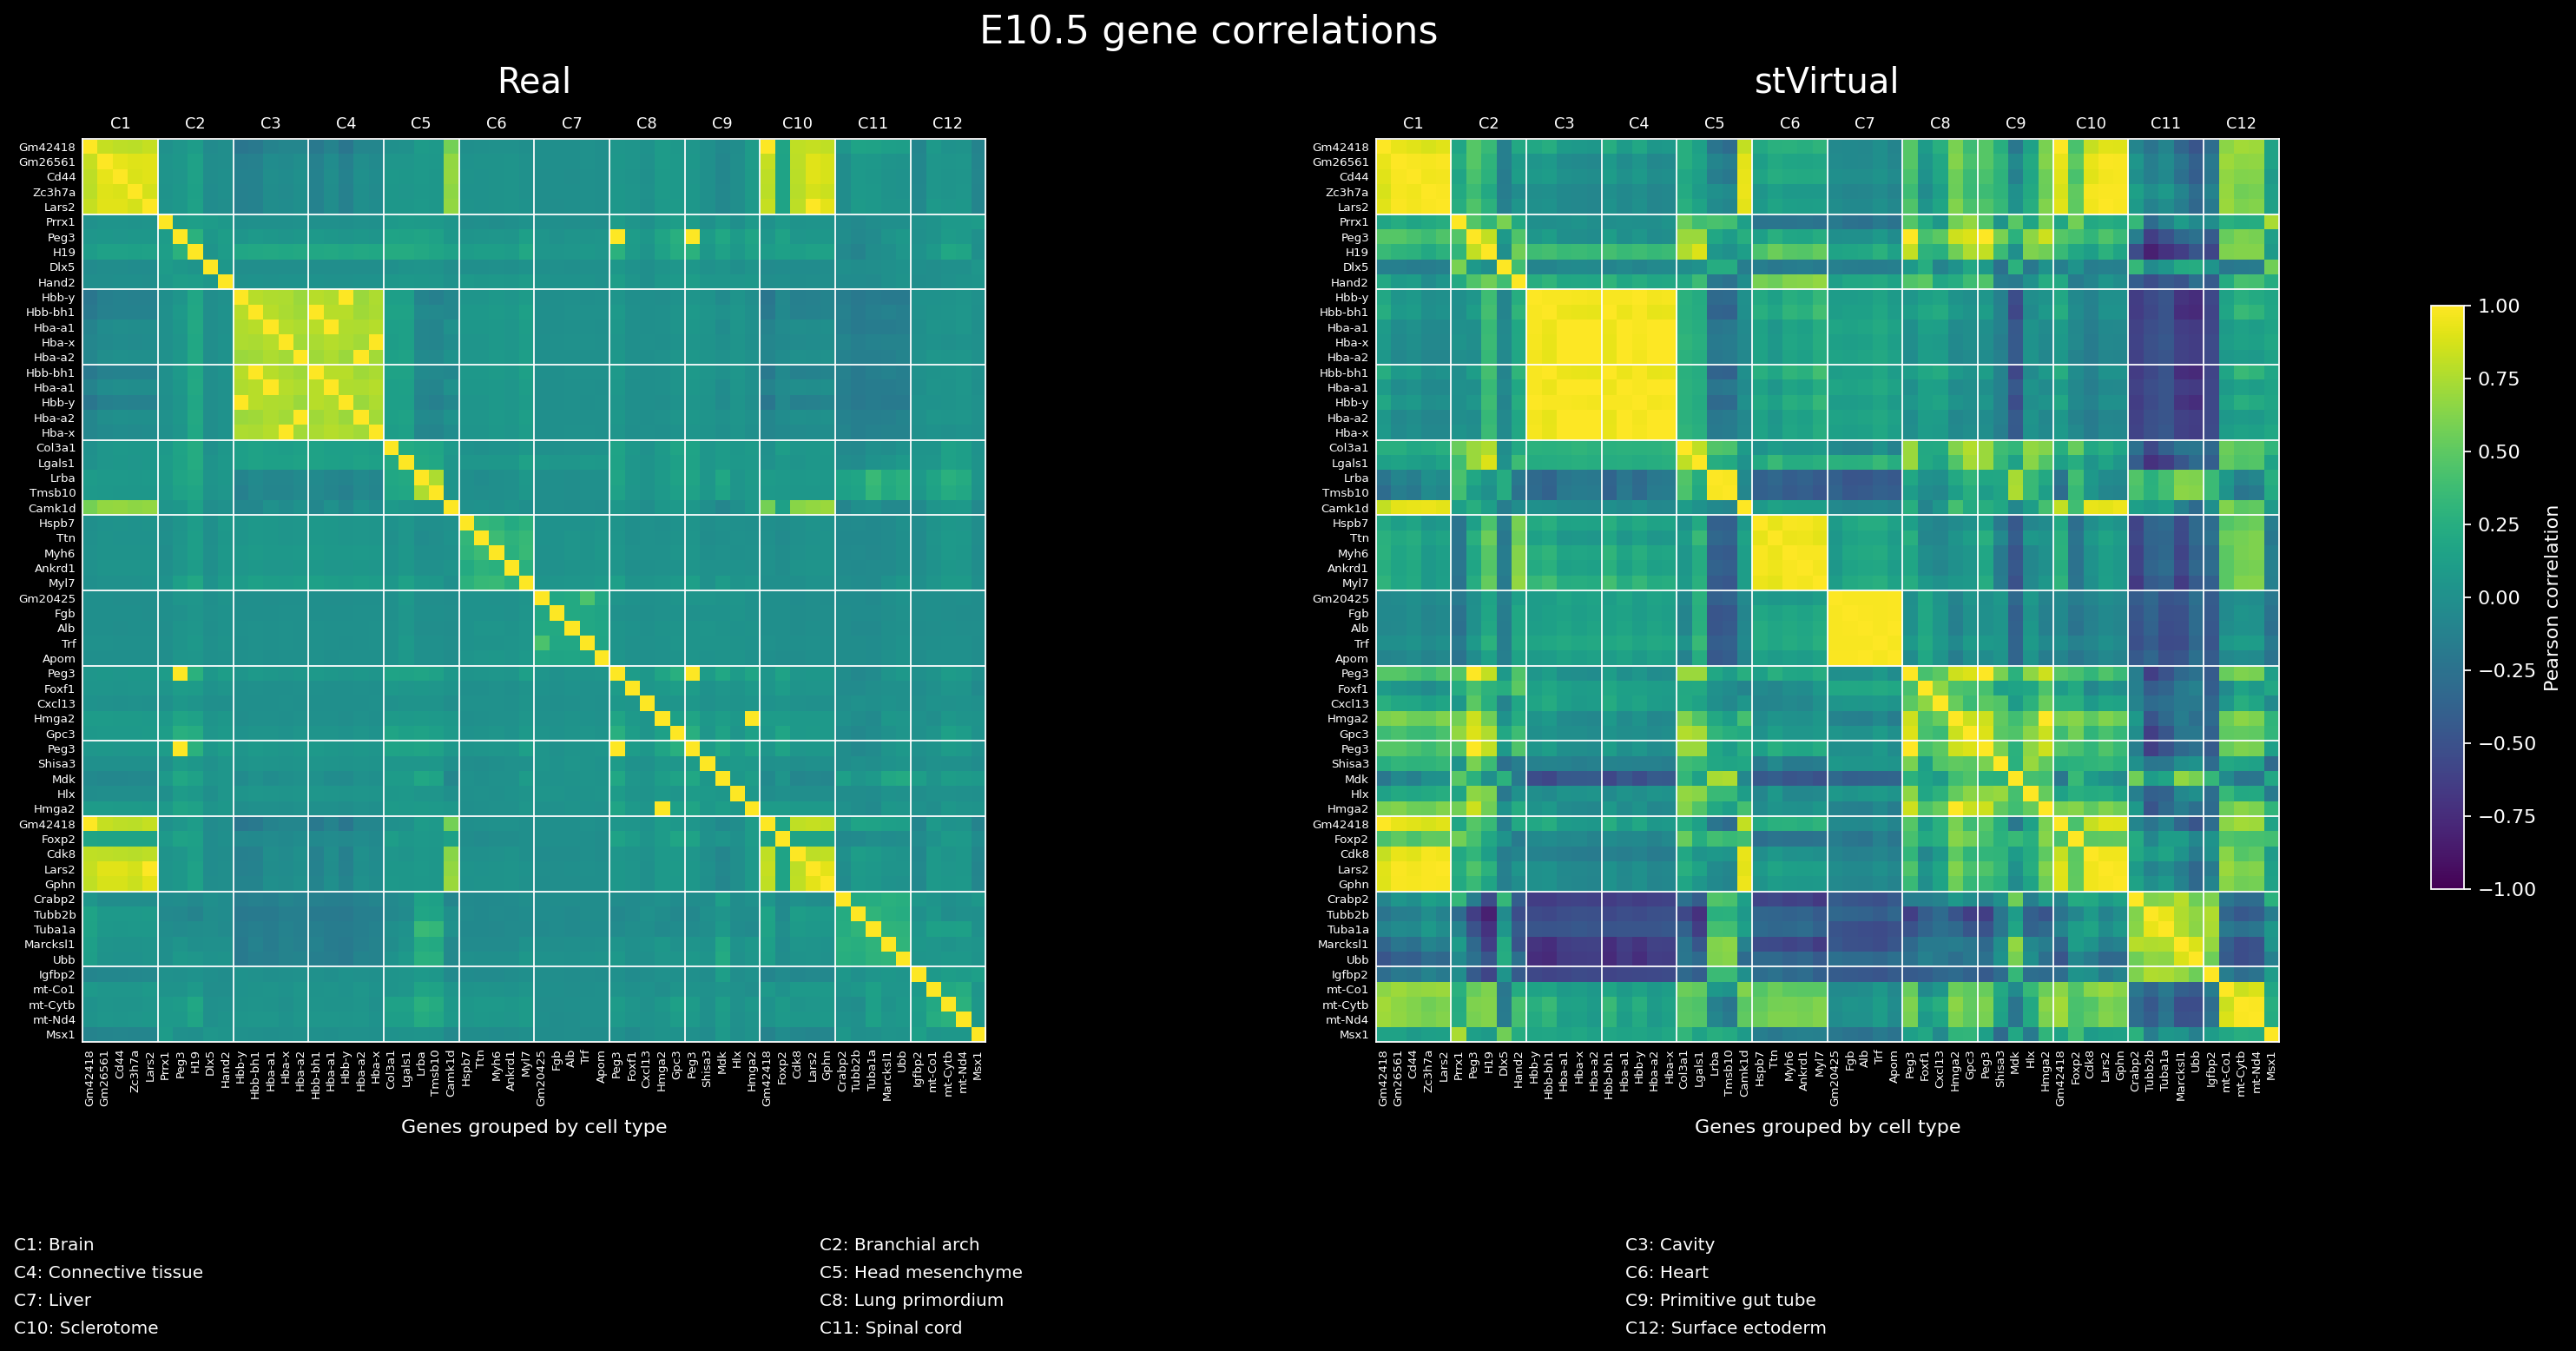

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CORRELATION_DIR = EXPERIMENT_DIR / "correlation_results"
markers = pd.read_csv(CORRELATION_DIR / "heatmap_gene_order.csv")
cluster_key = pd.read_csv(CORRELATION_DIR / "heatmap_cluster_key.csv")
slots = markers.slot_id.tolist()
sizes = markers.groupby("cluster", sort=False).size().to_numpy()
boundaries = np.cumsum(sizes)
centers = (np.r_[0, boundaries[:-1]] + boundaries - 1) / 2
fig, axes = plt.subplots(1, 2, figsize=(20, 10), dpi=160)
fig.patch.set_facecolor("black")
for ax, method in zip(axes, ["Real", "stVirtual"]):
    table = pd.read_csv(CORRELATION_DIR / f"{method}_correlation.csv", index_col=0)
    assert table.index.tolist() == slots and table.columns.tolist() == slots
    matrix = table.to_numpy(float)
    assert np.isfinite(matrix).all()
    assert np.allclose(matrix, matrix.T, atol=1e-8)
    assert np.allclose(np.diag(matrix), 1)
    ax.set_facecolor("black")
    image = ax.imshow(matrix, cmap="viridis", vmin=-1, vmax=1,
                      interpolation="nearest", aspect="equal")
    for edge in boundaries[:-1] - 0.5:
        ax.axvline(edge, color="white", lw=0.8)
        ax.axhline(edge, color="white", lw=0.8)
    ax.set_xticks(range(len(markers)), markers.gene, rotation=90, fontsize=6)
    ax.set_yticks(range(len(markers)), markers.gene, fontsize=6)
    top = ax.secondary_xaxis("top")
    top.set_xticks(centers, cluster_key.cluster_id, fontsize=8)
    top.tick_params(colors="white", length=0)
    ax.tick_params(colors="white", length=0)
    ax.set_title(method, color="white", fontsize=18, pad=24)
    ax.set_xlabel("Genes grouped by cell type", color="white", labelpad=7)
    for spine in ax.spines.values():
        spine.set_color("white")
fig.subplots_adjust(left=0.06, right=0.92, bottom=0.24, top=0.89, wspace=0.18)
cax = fig.add_axes([0.94, 0.35, 0.012, 0.42])
bar = fig.colorbar(image, cax=cax)
bar.set_label("Pearson correlation", color="white")
bar.ax.tick_params(colors="white")
bar.outline.set_edgecolor("white")
for i, row in cluster_key.iterrows():
    fig.text(0.07 + (i % 3) * 0.29, 0.09 - (i // 3) * 0.02,
             f"{row.cluster_id}: {row.cluster}", color="white", fontsize=9)
fig.suptitle("E10.5 gene correlations", color="white", fontsize=20, y=0.98)
plt.show()


## Embryo development, E9.5–E15.5

Simulation results, arranged by time.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DEVELOPMENT_DIR = EXPERIMENT_DIR / "development_results"
development_info = json.loads((DEVELOPMENT_DIR / "provenance.json").read_text())
development_frames = []
development_labels = development_info["labels"]
development_colors = np.array([development_info["palette"][label]
                              for label in development_labels])
for frame in development_info["frames"]:
    with np.load(DEVELOPMENT_DIR / f"frame_{frame['index']:03d}.npz", allow_pickle=False) as data:
        development_frames.append({**frame, "xy": data["xy"].copy(),
                                    "labels": data["labels"].copy()})
assert len(development_frames) == 61
assert development_frames[0]["day"] == 9.5 and development_frames[-1]["day"] == 15.5
xy_all = np.concatenate([frame["xy"] for frame in development_frames])
x_span, y_span = np.ptp(xy_all, axis=0)
z_step = max(x_span, y_span) * 0.09

def plot_development_stack(ax, tissue=None):
    ax.set_facecolor("black")
    drawn = []
    for i, frame in enumerate(development_frames):
        xy, labels = frame["xy"], frame["labels"]
        if tissue is None or i in [0, len(development_frames) - 1]:
            mask = np.ones(len(xy), dtype=bool)
            size, alpha = 2, 0.95
        else:
            if i % 3:
                continue
            mask = labels == development_labels.index(tissue)
            size, alpha = 0.75, 0.1
        if not mask.any():
            continue
        x = xy[mask, 0]
        depth = np.full(mask.sum(), i * z_step)
        y = -xy[mask, 1]
        ax.scatter(x, depth, y, c=development_colors[labels[mask]],
                   s=size, alpha=alpha, linewidths=0, depthshade=False, rasterized=True)
        drawn.append(np.column_stack([x, depth, y]))
    if tissue is not None:
        points = np.concatenate(drawn)
        low, high = np.percentile(points, [1, 99], axis=0)
        pad = np.maximum(high - low, 1e-8) * 0.08
        ax.set_xlim(low[0] - pad[0], high[0] + pad[0])
        ax.set_ylim(low[1] - pad[1], high[1] + pad[1])
        ax.set_zlim(low[2] - pad[2], high[2] + pad[2])
    ax.view_init(elev=3, azim=-75, roll=8)
    ax.set_proj_type("ortho")
    ax.set_box_aspect((x_span, (len(development_frames) - 1) * z_step * 1.45, y_span * 0.9), zoom=3.0)
    ax.set_axis_off()
    ax.text2D(0.04, 0.05, "E9.5 → E15.5", transform=ax.transAxes, color="white", fontsize=11)
    if tissue:
        ax.set_title(tissue, color="white", fontsize=16, pad=0)


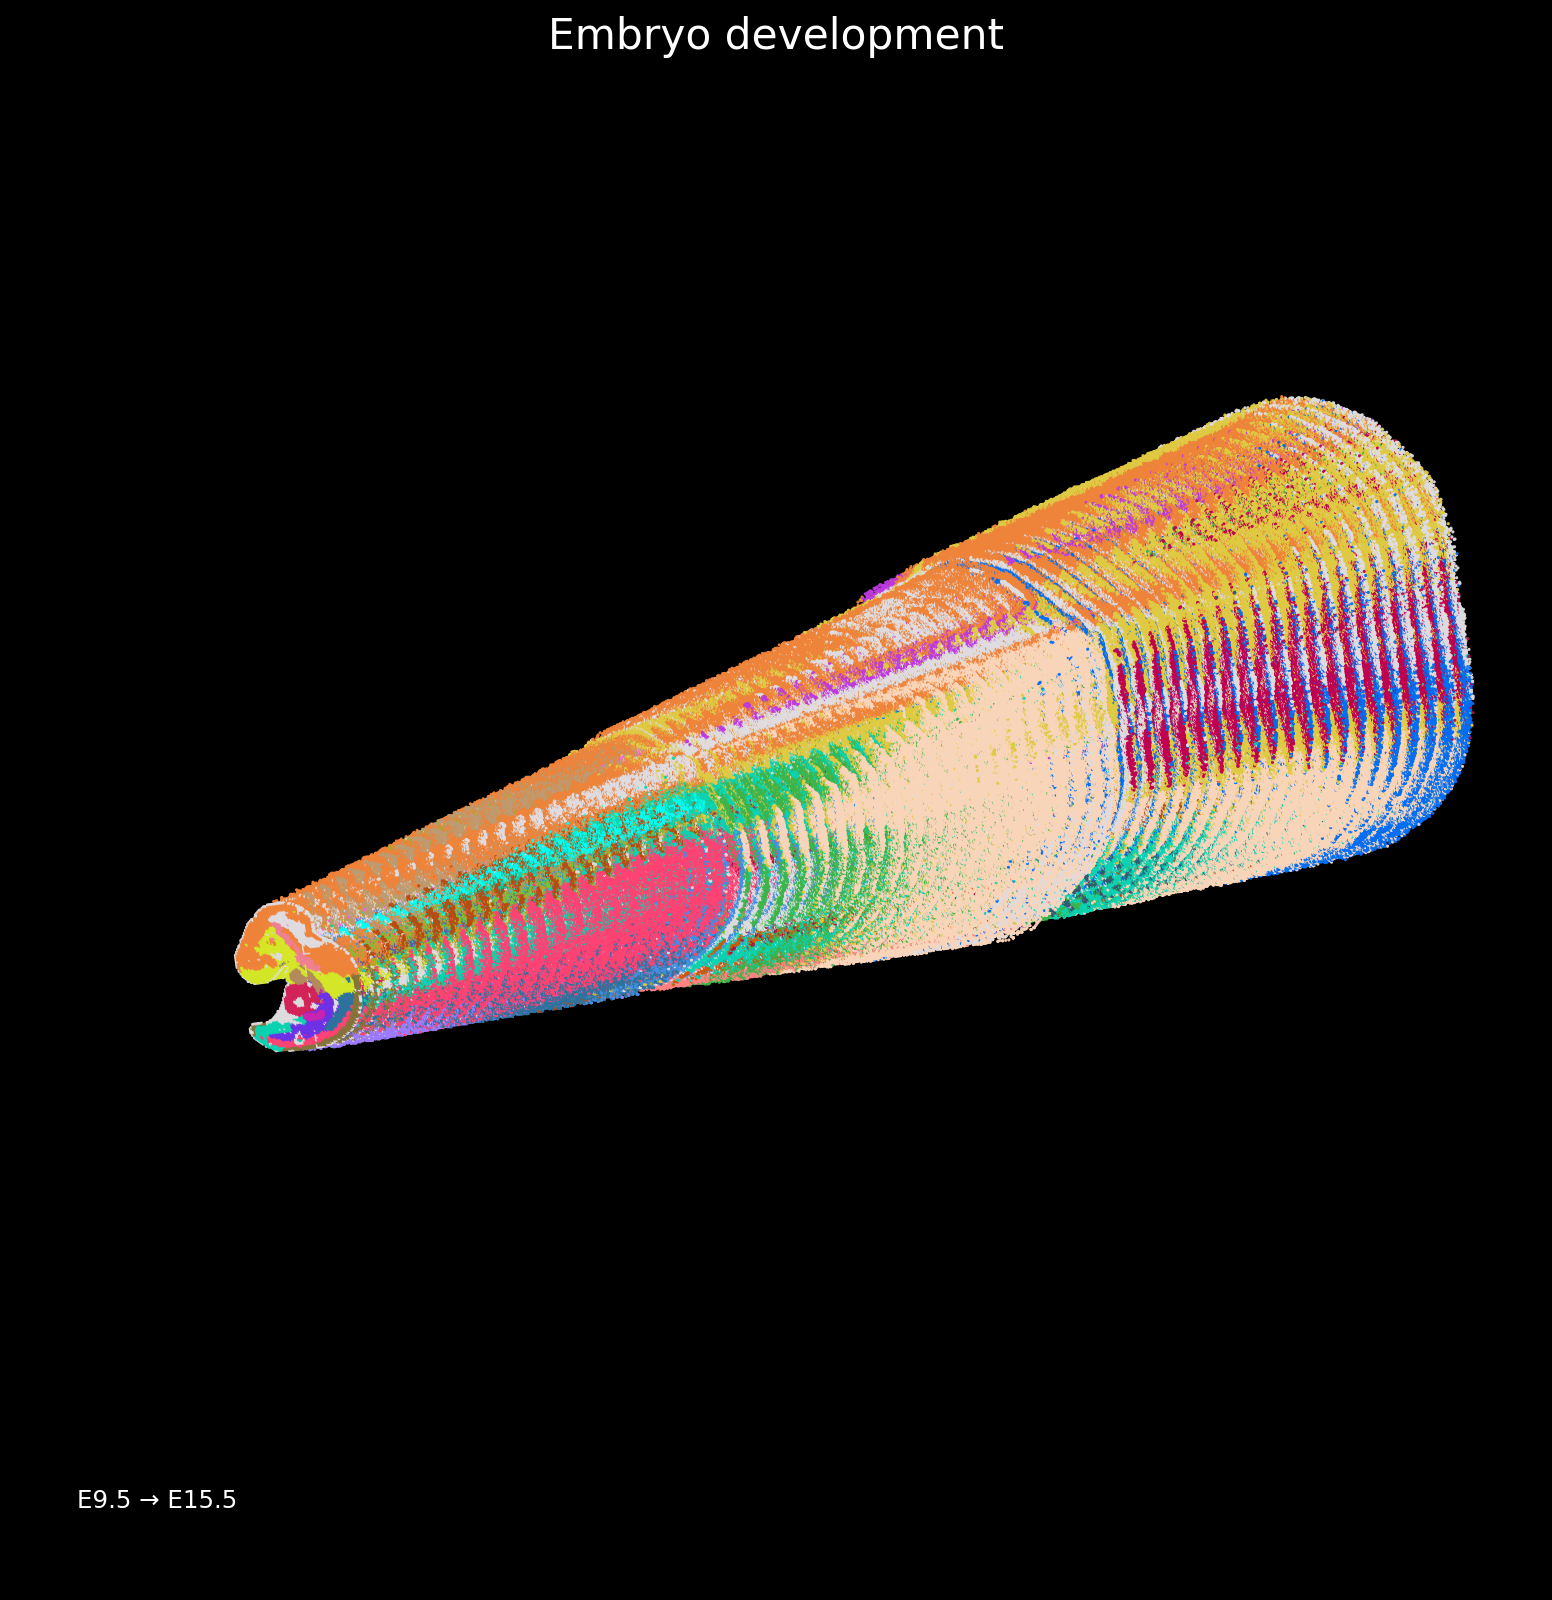

In [4]:
fig = plt.figure(figsize=(12, 10), dpi=160, facecolor="black")
ax = fig.add_subplot(111, projection="3d")
plot_development_stack(ax)
fig.suptitle("Embryo development", color="white", fontsize=19, y=0.98)
fig.subplots_adjust(left=0, right=1, bottom=0, top=0.95)
plt.show()


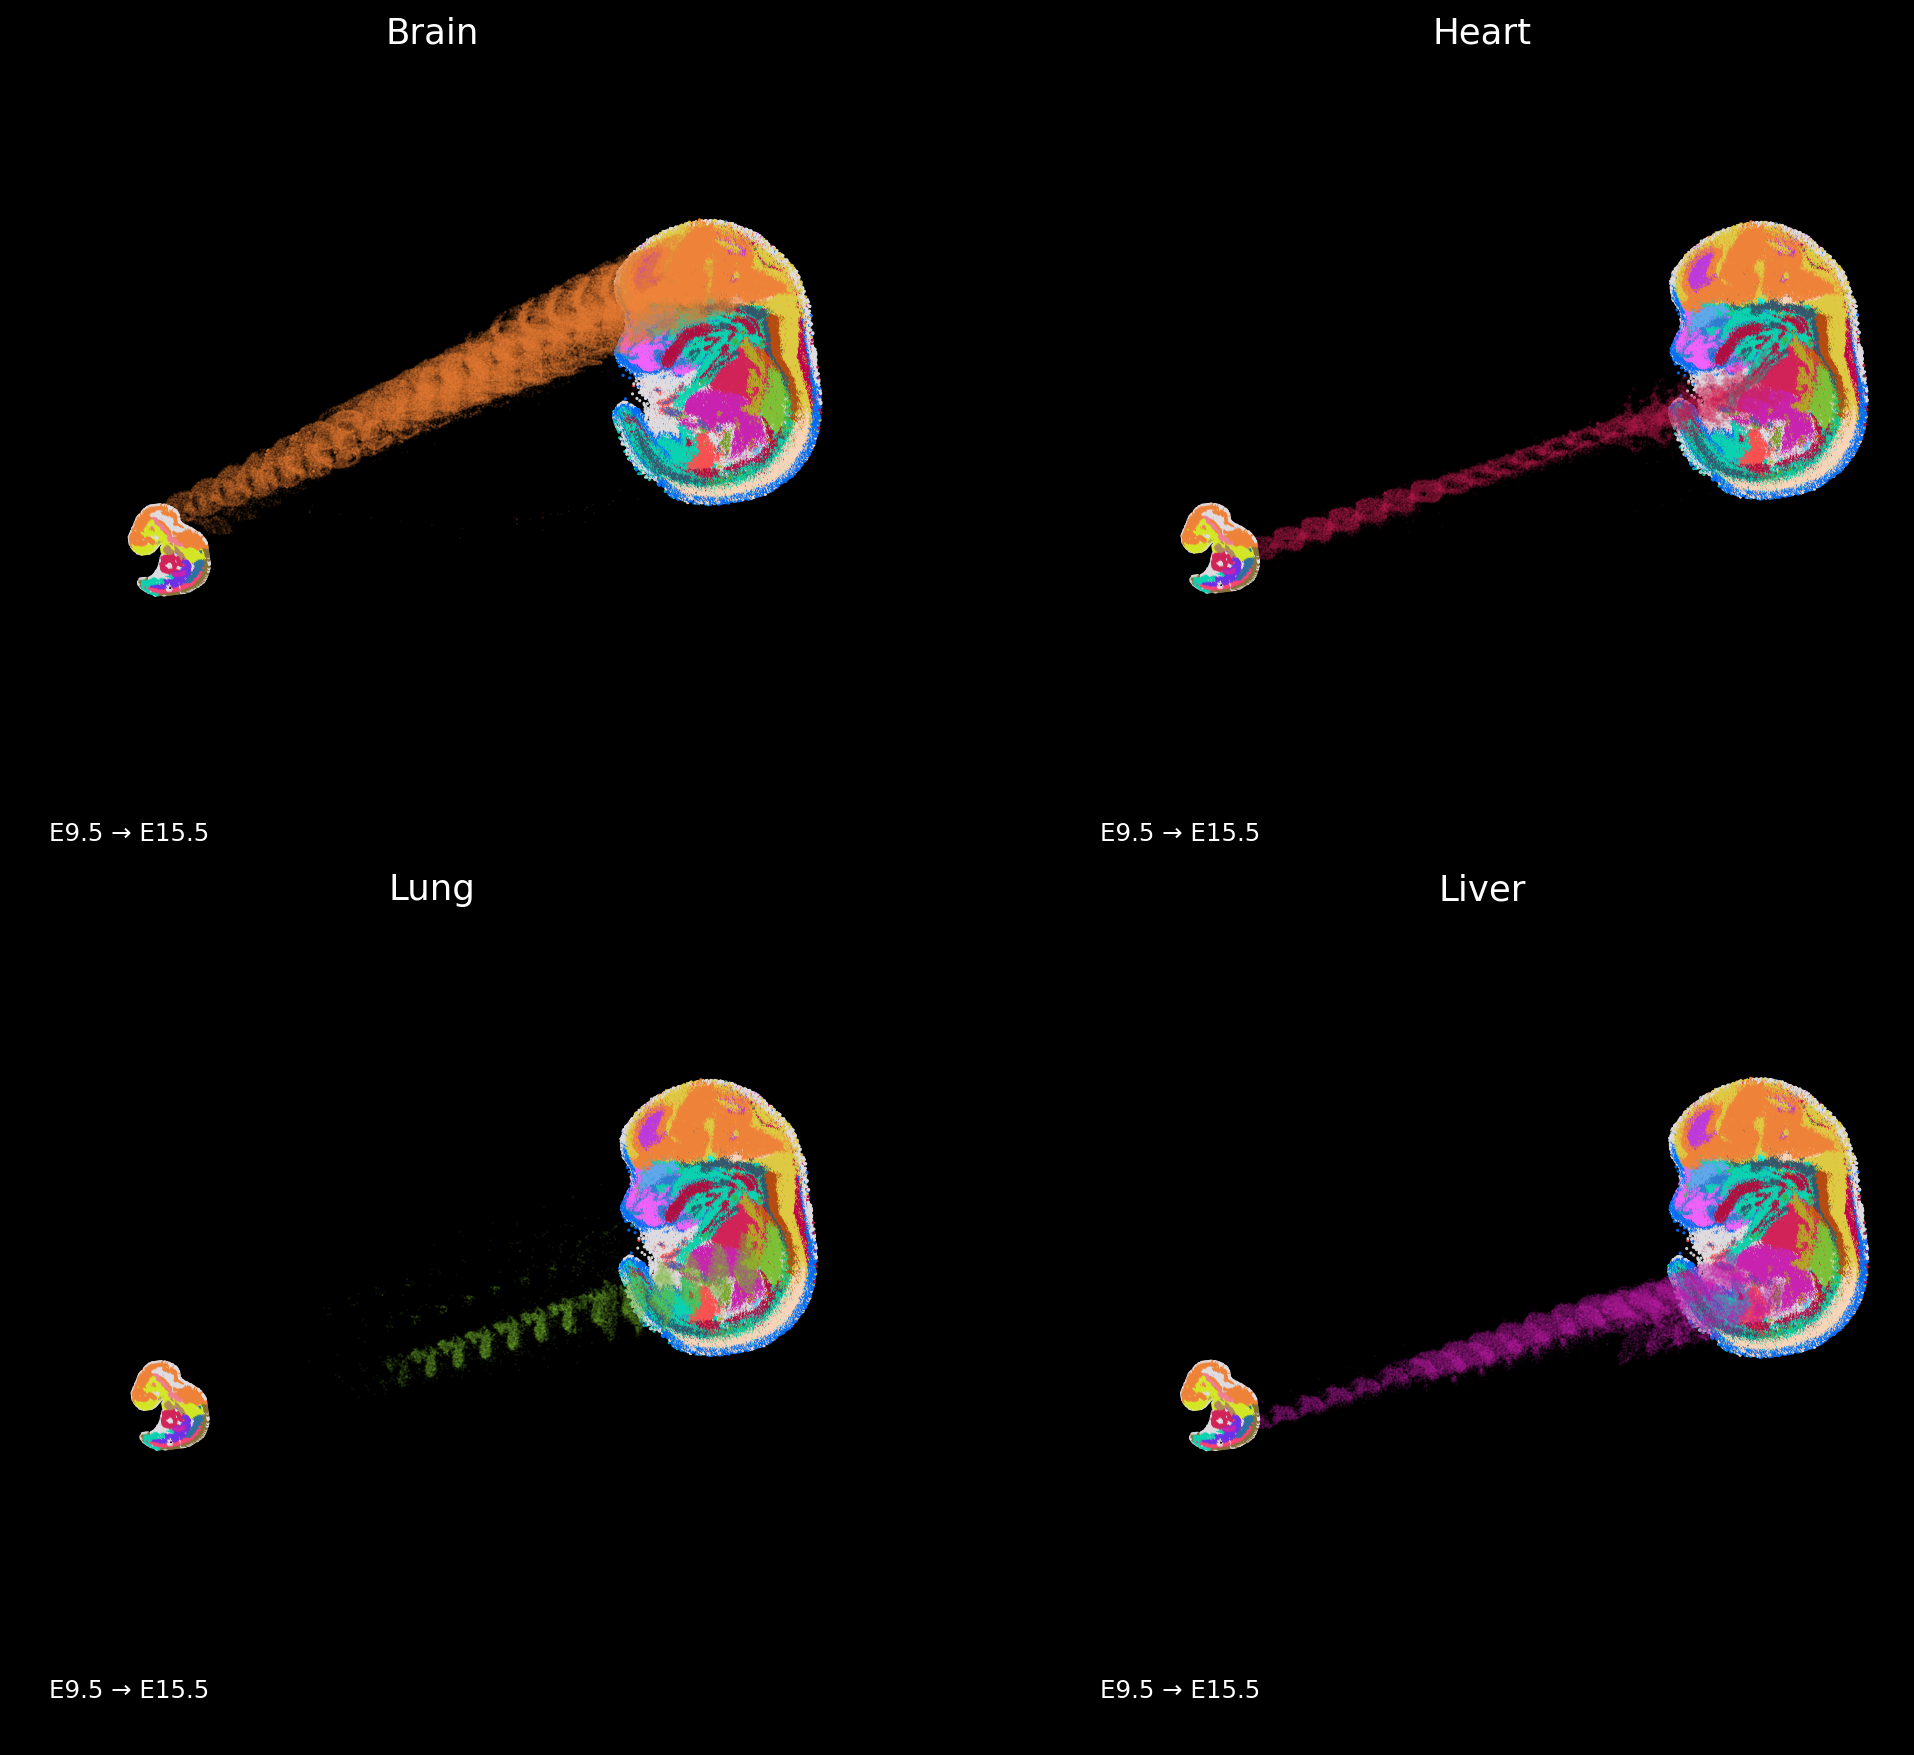

In [5]:
fig = plt.figure(figsize=(13, 11), dpi=160, facecolor="black")
for i, tissue in enumerate(["Brain", "Heart", "Lung", "Liver"], start=1):
    ax = fig.add_subplot(2, 2, i, projection="3d")
    plot_development_stack(ax, tissue=tissue)
fig.subplots_adjust(left=0, right=1, bottom=0, top=0.96, hspace=0.03, wspace=0.02)
plt.show()


## Mean gene expression

Real and stVirtual for three windows: E9.5–E11.5, E11.5–E13.5 and E13.5–E15.5.

Values: **log1p(mean(CP10k))**, including zeros. Read the saved results.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

EXPRESSION_DIR = EXPERIMENT_DIR / "expression_results"
expression_info = json.loads((EXPRESSION_DIR / "provenance.json").read_text())
assert expression_info["metric"] == "log1p(mean(CP10k))"
assert expression_info["methods"] == ["Real", "stVirtual"]
assert len(expression_info["windows"]) == 3
expression_windows = []
for window in expression_info["windows"]:
    table = pd.read_csv(
        EXPRESSION_DIR / window["cache"], float_precision="round_trip",
        keep_default_na=False, dtype={"gene": str},
    )
    assert list(table.columns) == ["gene", "Real", "stVirtual"]
    assert len(table) == window["n_genes"] and table["gene"].is_unique
    values = table[["Real", "stVirtual"]].to_numpy()
    assert np.isfinite(values).all() and (values >= 0).all()
    expression_windows.append((window, table))


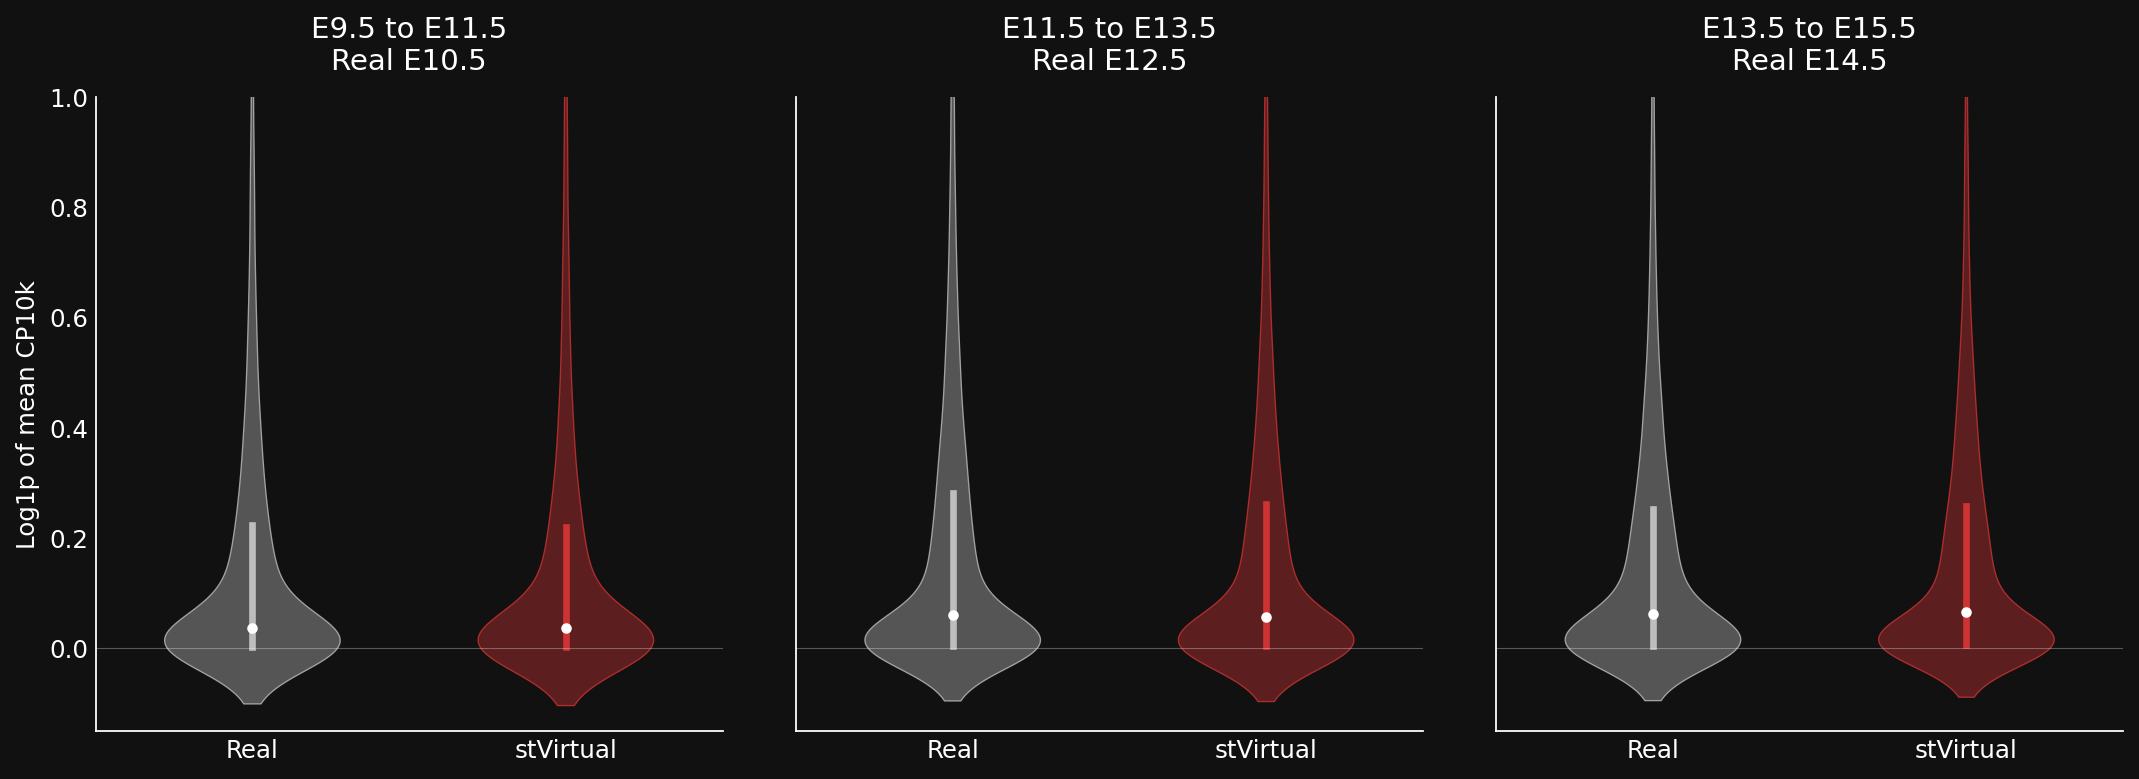

In [3]:
from matplotlib.colors import to_rgba

with plt.rc_context({"font.family": "DejaVu Sans", "font.size": 11}):
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 5), dpi=160, sharey=True)
    fig.patch.set_facecolor("#111111")
    ymin, ymax = expression_info["axis_limits"]
    methods = expression_info["methods"]
    for ax, (window, table) in zip(axes, expression_windows):
        ax.set_facecolor("#111111")
        for position, method in enumerate(methods):
            values = table[method].to_numpy()
            density = gaussian_kde(values, bw_method="scott")
            bandwidth = float(np.sqrt(density.covariance[0, 0]))
            lower = values.min() - 2 * bandwidth
            upper = values.max() + 2 * bandwidth
            grid = np.unique(np.r_[np.linspace(lower, upper, 250), np.linspace(lower, ymax, 400)])
            width = density(grid)
            width *= 0.28 / width.max()
            color = expression_info["colors"][method]
            ax.fill_betweenx(grid, position - width, position + width,
                             facecolor=to_rgba(color, 0.4), edgecolor=to_rgba(color, 0.8), linewidth=0.6)
            q25, median, q75 = np.quantile(values, [0.25, 0.5, 0.75])
            ax.plot([position, position], [q25, q75], color=color, linewidth=3)
            ax.scatter(position, median, color="white", s=14, zorder=4)
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(ymin, ymax)
        ax.set_xticks([0, 1], methods)
        ax.set_title(f'{window["display_window"]}\nReal {window["display_middle"]}', color="white", pad=12)
        ax.tick_params(colors="white", length=0)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("white")
        ax.axhline(0, color="white", linewidth=0.5, alpha=0.3)
        ax.grid(False)
    axes[0].set_ylabel("Log1p of mean CP10k", color="white")
    fig.tight_layout(w_pad=3)
    plt.show()
